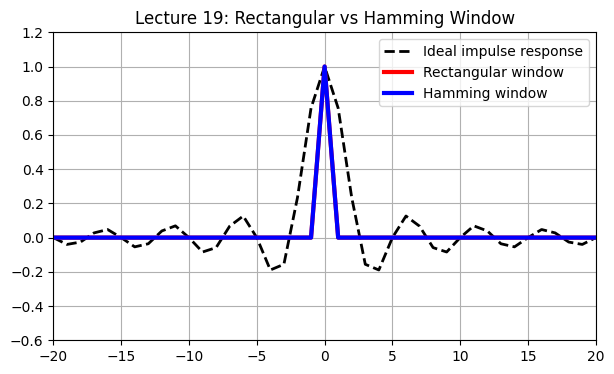

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 19: Window Comparison
# Same animation style as Lecture 9
# -----------------------------

# Time axis
N = 41
n = np.arange(-(N//2), N//2 + 1)

# Ideal low‑pass impulse response
wc = 0.4 * np.pi
h_ideal = np.sinc((wc/np.pi) * n)

# Windows
rect_window = np.ones_like(n)
hamming_window = np.hamming(len(n))

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(min(n), max(n))
ax.set_ylim(-0.6, 1.2)
ax.grid(True)
ax.set_title("Lecture 19: Rectangular vs Hamming Window")

# Reference ideal impulse response
ax.plot(n, h_ideal, 'k--', lw=2, label="Ideal impulse response")

# Animated windowed responses
rect_line, = ax.plot([], [], 'r', lw=3, label="Rectangular window")
ham_line,  = ax.plot([], [], 'b', lw=3, label="Hamming window")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    h_rect = np.zeros_like(h_ideal)
    h_ham  = np.zeros_like(h_ideal)

    center = len(n) // 2
    half = frame // 2

    start = max(center - half, 0)
    end   = min(center + half + 1, len(n))

    h_rect[start:end] = h_ideal[start:end] * rect_window[start:end]
    h_ham[start:end]  = h_ideal[start:end] * hamming_window[start:end]

    rect_line.set_data(n, h_rect)
    ham_line.set_data(n, h_ham)

    return rect_line, ham_line

anim = FuncAnimation(fig, update, frames=len(n), interval=200)

HTML(anim.to_jshtml())

Red (rectangular) coefficients turn on abruptly
Blue (Hamming) coefficients taper smoothly
Both approximate the same ideal impulse response
But their time‑domain behavior differs visibly